In [4]:
import sys
import os
from pathlib import Path

package_path = Path(os.path.abspath("")).parent


Image shape: (4999, 5000, 3)
Loaded cached masks.
Filtering masks...
Most common largest cluster size: 9 out of 35 total masks.
Chosen parameters: eps=760.0, min_samples=1
Filtering completed with chosen parameters: (np.float64(760.0), 1)


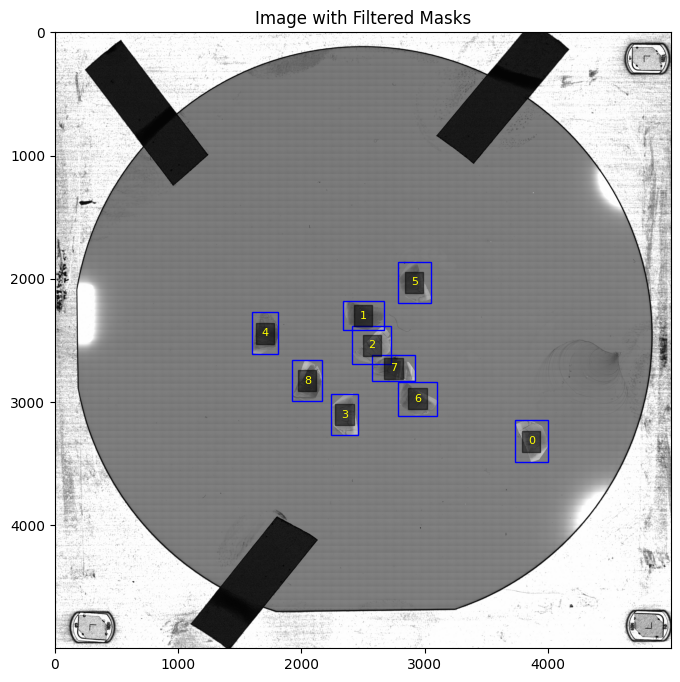

Number of masks identified: 9


In [5]:
from section_identification.preprocess import preprocess_image
from section_identification.filtering import filtering
from section_identification.section_detector import automatic_identification

apply_filtering = True

image1 = package_path / "images/example1.png"
image2 = package_path / "images/example2.png"
image3 = package_path / "images/example3.png"
image4 = package_path / "images/example4.png"
jellyfish = package_path / "images/jellyfish.png"

# the weights can be downloaded from: https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
checkpoint = package_path.parents[0] / "checkpoint/sam_vit_h_4b8939.pth" 

# Write filtering=True to only identify sections
masks = automatic_identification(image4, checkpoint=checkpoint, compress=False, apply_filtering=True)
print(f"Number of masks identified: {len(masks)}")


In [6]:
from section_identification.interactive import run_sam_interactive

new_masks, stored_masks, fiducials = run_sam_interactive(image4, checkpoint, masks, model_type="vit_h", device="cpu")

Quantized ONNX model already exists: /Users/fredericoaraujo/Documents/section_identification/images/example4_files/example4_onnx_quantized.onnx
[Info] Embedding already exists: /Users/fredericoaraujo/Documents/section_identification/images/example4_files/example4_embedding.npy
Image size: 5000x4999 (width x height), samScale: 0.205
[Info] Starting interactive segmentation. Move the mouse over the image to update mask.
New mask added at position (3415, 831, 1)
Mask found at location (3415, 831).
Press 'r' again to confirm deletion of the highlighted mask, or any other key to cancel.
Deleted mask from new_masks.
Mask found at location (3840, 3301).
Press 'r' again to confirm deletion of the highlighted mask, or any other key to cancel.
Deleted mask from stored_masks.
New mask added at position (3904, 3279, 1)
[Info] Exiting interactive segmentation.


Exported mask coordinates to /Users/fredericoaraujo/Documents/section_identification/images/example4_files/example4_mask_coordinates.csv


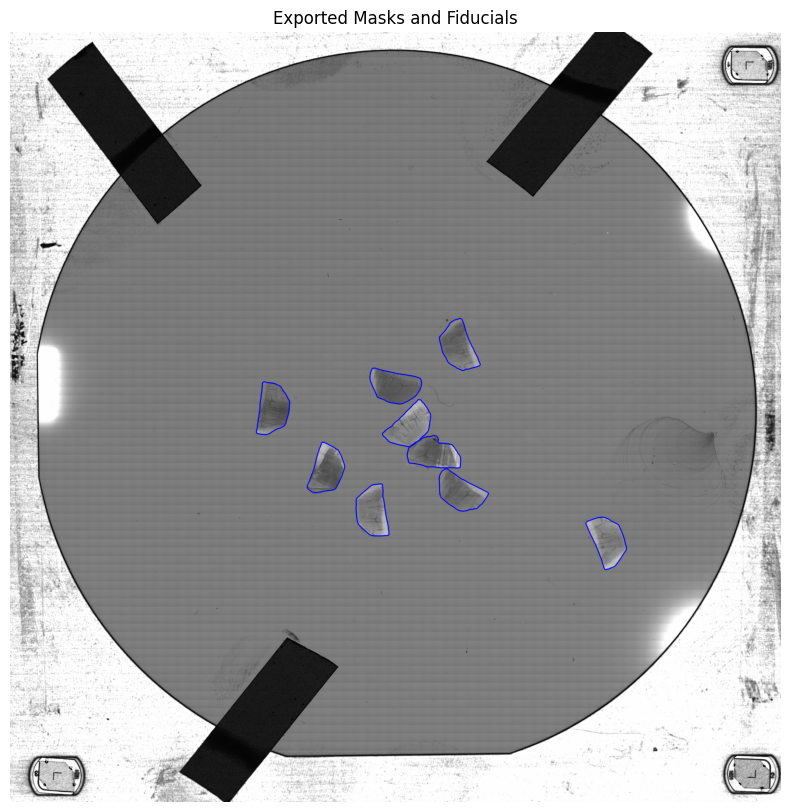

'/Users/fredericoaraujo/Documents/section_identification/images/example4_files/example4_mask_coordinates.csv'

In [7]:
from section_identification.export import export_mask_coordinates
export_mask_coordinates(image4, new_masks, stored_masks, fiducials, visualize=True)